# Modelo de examen - Práctica

In [8]:
#@title Ejecuta esta celda para cargar los datasets
!wget https://github.com/danteBenitez/modelo-examen-practica/raw/refs/heads/main/albums.db
!wget https://github.com/danteBenitez/modelo-examen-practica/raw/refs/heads/main/tracks.json

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


## Entrega

- Durante la actividad se pedirá que limpies el dataframe original. Al final, debes guardar el dataset limpio (con datos de las canciones y sus álbumes) en una base de datos SQLite, en una tabla `canciones`.
- El Jupyter Notebook deberá entregarse **ejecutado**, con los resultados y gráficos incluidos.
- Las justificaciones y explicaciones deberán hacerse en celdas Markdown.

# Situación problemática

El sistema de una tienda musical sufrió daños y no todos los datos se recuperaron; otros sufrieron una corrupción. Los dato están divididos en dos grupos:
- Los albumes ofrecidos en la tienda se guardan en un archivo de base de datos SQLite, en una tabla `albums`.
- Las canciones se recuperaron aparte, en un archivo `canciones.json`.

**Objetivo**: Auditar, limpiar y evaluar la calidad de los datos. Luego, elaborar un reporte con gráficos con las conclusiones que se puedan extraer de los datos limpios.

In [9]:
import pandas as pd

## Actividad 1

- Realiza un diagnóstico técnico de los datos en `canciones.json`. Informa:
  - qué columnas tienen valores nulos,
  - cuál es el tipo actual de cada uno, y
  - si existen columnas que requerirán una transformación previa antes de trabajar con ellas.

In [10]:
df = pd.read_json('tracks.json')
df.info()
df.head()

FileNotFoundError: File tracks.json does not exist

In [ ]:
df.isnull().sum()


,0
AlbumId,9
TrackName,0
Milliseconds,0
Bytes,0
UnitPrice,17
GenreName,0


Existen **26** valores nulos, los datos de las columnas tienen diferentes tipos, tambien podemos ver que habra que transformar **AlbumId** porque tiene valores nulos, el **unitPrice** tambien tiene valores nulosy como podemos ve su ttipo de datos es object lo que quiere decir que tiene signos $ o USD, el **GenereName** tiene diferentes formatos

- Observa los datos almacenados en el archivo SQLite. ¿Qué columna podemos usar para combinar información de ambos datasets?

Observando el archivo albums.db noto que hay una columna llamada AlbumId al igual que el dataset, asi que podriamos usar esa columna para conbinar la informacion de ambos datasets

## Actividad 2: Limpieza

- Los géneros musicales se grabaron de forma inconsistente (ej: "ROCK", "rock ", " Rock"). Incluso hay nombres con caracteres especiales. Explora estas inconsistencias y normaliza todos los géneros para que el inventario sea coherente.

In [ ]:
df['GenreName'].unique()

array(['rock', '   rock!!!', 'ROCK', '   ROCK!!!', '   rock ', '   ROCK ',
       'LATIN', '   latin ', 'latin', '   LATIN!!!', '   LATIN ',
       '   latin!!!', 'reggae', '   REGGAE!!!', 'REGGAE', '   REGGAE ',
       '   reggae!!!', '      ROCK !!!', '      latin !!!',
       'ALTERNATIVE & PUNK', '   alternative & punk!!!',
       'alternative & punk', '   alternative & punk ',
       '   ALTERNATIVE & PUNK!!!', '   EASY LISTENING!!!',
       'EASY LISTENING', '   easy listening ', 'easy listening',
       '   easy listening!!!', '      EASY LISTENING !!!', 'SOUNDTRACK',
       '   SOUNDTRACK ', 'soundtrack', '   SOUNDTRACK!!!',
       '   soundtrack!!!', '      soundtrack !!!', 'metal', '   metal!!!',
       'METAL', '   METAL!!!', '   metal ', '   R&B/SOUL!!!', 'r&b/soul',
       '   r&b/soul!!!', 'R&B/SOUL', '   r&b/soul ',
       '      ALTERNATIVE & PUNK !!!', '   METAL ', '   soundtrack ',
       'hip hop/rap', '   HIP HOP/RAP!!!', 'HIP HOP/RAP',
       '   hip hop/rap!!!', '

In [ ]:
df['GenreName'] = df['GenreName'].str.lower()
df['GenreName'] = df['GenreName'].str.strip()
# eliminar los signos !!!
df['GenreName'] = df['GenreName'].str.replace('!!!', '')
df['GenreName'].unique()

array(['rock', 'latin', 'reggae', 'rock ', 'latin ', 'alternative & punk',
       'easy listening', 'easy listening ', 'soundtrack', 'soundtrack ',
       'metal', 'r&b/soul', 'alternative & punk ', 'hip hop/rap', 'blues',
       'blues ', 'tv shows', 'metal ', 'pop', 'classical', 'classical ',
       'alternative'], dtype=object)

- Parece haber errores en la columna de precios. Identifica cuáles son y emplea estrategias de limpieza para solucionarlos. Listar qué problemas se encontraron.

In [ ]:
df['UnitPrice'].unique()

array(['$0.99 USD', '$nan', '0.99', '$0.99', '$nan USD', None, '$1.99',
       '$1.99 USD', '1.99'], dtype=object)

In [ ]:
df['UnitPrice'] = df['UnitPrice'].astype(str).str.replace('$', '', regex=False).str.replace(' USD', '', regex=False).str.strip()

df['UnitPrice'] = df['UnitPrice'].replace('$nan', pd.NA)

df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')

df.info()
df.head()

NameError: name 'df' is not defined

Problemas encontrados:


1.   Signos como "$" y USD en los precios
2.   Habia datos con "$$nan"
3. La columna tenia el tipo de dato object



Con esto, la columna `UnitPrice` debería estar limpia y en formato numérico, lista para ser usada en cálculos. Observamos que `df.info()` ahora muestra `UnitPrice` como `float64` y `df.head()` ya no tiene los símbolos.

- ¿Existen precios con valores nulos? Elige entre completar los valores con NaN, eliminar las filas o usar algún otro valor. Justifica tu elección.

In [ ]:
# ver las filas y columnas
df.shape

(631, 6)

In [ ]:
# eliminar los datos nulos de UnitPrice
df.dropna(subset=['UnitPrice'], inplace=True)
# ver si quedan dato nulos en UnitPrice
df['UnitPrice'].isnull().sum()
# Eliminé los datos nulos porque solo eran aprox 17 y eran más de 600 filas, por lo tanto no hay un daño muy grande si se elimina


np.int64(0)

- Se han detectado "pistas fantasma" con duraciones imposibles (menos de 10 segundos o más de 20 minutos). Elimínalas para que no afecten las estadísticas de la tienda.

In [ ]:
#  eliminar pistas con más de 1200000 milisegundos o menos de 10000 milisegundos
df = df[(df['Milliseconds'] >= 10000) & (df['Milliseconds'] <= 1200000)]

df.head()
# verificar que se haya limpiados filtrando
df[(df['Milliseconds'] < 10000) | (df['Milliseconds'] > 1200000)]

,AlbumId,TrackName,Milliseconds,Bytes,UnitPrice,GenreName


## Actividad 3: Reconstrucción

- **Reconstruye el inventario**. Combina la información de los albumes con sus canciones, utilizando la columna identificada en la Actividad 1.

**Pista**: Deberás usar la función `pd.merge()` de Pandas. De la siguiente manera:

```py
combined = pd.merge(df1, df2, on='<columna>')
```

- ¿Qué cantidad de registros esperas que tenga el dataframe obtenido? Verifica si se cumple o no tu expectativa.

In [ ]:
# importamos sqlite para usarlo
import sqlite3
conn = sqlite3.connect('albums.db')
df_albums = pd.read_sql_query('SELECT * FROM albums', conn)
df_albums.head()


,index,AlbumId,Title,ArtistId
0,0,323,Carried to Dust (Bonus Track Version),253
1,1,115,Sex Machine,91
2,2,326,Mendelssohn: A Midsummer Night's Dream,256
3,3,268,The Best of Beethoven,203
4,4,308,"Tchaikovsky: 1812 Festival Overture, Op.49, Ca...",243


In [ ]:
# cuántas canciones tienen AlbumId válido
df['AlbumId'].notnull().sum()
# Se espera que tengan 556 registros
# merge
combined = pd.merge(df, df_albums, on='AlbumId')

# ver cuantos registros quedaron
combined.shape
# tuvo 556

(556, 9)

- ¿Todos las canciones pertenecen a un album? Si es posible, calcula cuánto dinero representan esas canciones perdidas.

In [ ]:
# averiguar si todas las canciones pertenecen a un album
# df['AlbumId'].isnull().sum()
# calcular cuanto dinero representan esas canciones perdidas
df[df['AlbumId'].isnull()]['UnitPrice'].sum()


np.float64(7.92)

* Hay 8 canciones que no pertenecen a algun album, representan 7.92 de dinero perdido

- Agrupa los datos por AlbumTitle. Calcula:
    - El número de canciones por álbum.
    - El precio total del álbum.
    - El tamaño total en Megabytes.

 - ¿Cuál es el álbum más caro de la tienda según tus cálculos?

In [ ]:
# calcular el numero de canciones por album
# combined.columns
combined.groupby('Title')['TrackName'].count()


,TrackName
Title,
"A Copland Celebration, Vol. I",1
A Soprano Inspired,1
A-Sides,15
Acústico,19
Acústico MTV [Live],16
Album Of The Year,12
Are You Experienced?,16
As Canções de Eu Tu Eles,13
Audioslave,14


In [ ]:
# el precio total del album
combined.groupby('Title')['UnitPrice'].sum()


,UnitPrice
Title,
"A Copland Celebration, Vol. I",0.99
A Soprano Inspired,0.99
A-Sides,14.85
Acústico,18.81
Acústico MTV [Live],15.84
Album Of The Year,11.88
Are You Experienced?,15.84
As Canções de Eu Tu Eles,12.87
Audioslave,13.86


In [ ]:
# el tamaño total en megabytes
combined.groupby('Title')['Bytes'].sum()

,Bytes
Title,
"A Copland Celebration, Vol. I",3211245
A Soprano Inspired,5605648
A-Sides,137160143
Acústico,122785772
Acústico MTV [Live],123722474
Album Of The Year,84680215
Are You Experienced?,112432356
As Canções de Eu Tu Eles,89904748
Audioslave,94304482


- Calcula el valor total del inventario (suma de unit_price) y la duración promedio de las canciones para cada género.

In [ ]:

combined['UnitPrice'].sum()

np.float64(550.44)

In [ ]:

combined.groupby('GenreName')['Milliseconds'].mean()

,Milliseconds
GenreName,
alternative,215386.000000
alternative & punk,207300.017544
alternative & punk,267154.000000
blues,338680.857143
blues,233639.000000
classical,313020.500000
classical,132932.000000
easy listening,189211.590909
easy listening,193175.000000


## Actividad 4: Gráficos

Responde a las siguientes actividades con un gráfico.
Asegúrate de:
- Elegir un título de gráfico adecuado.
- Elegir el tipo de gráfico correcto para lo que se quiere representar.
- Añadir etiquetas de eje y leyendas, de ser necesarias.

- ¿Qué géneros tenemos más en stock?

In [ ]:
import seaborn as sns

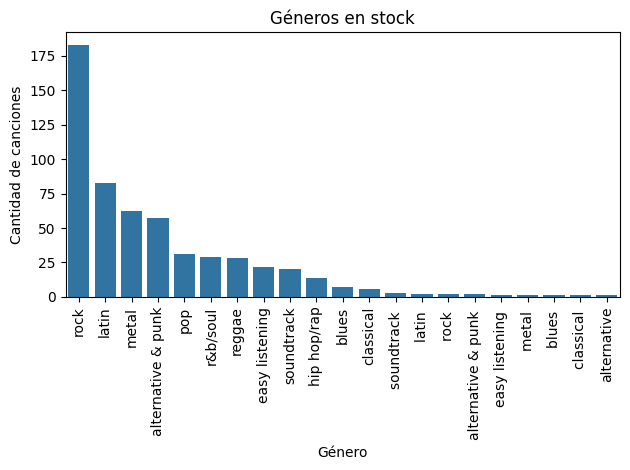

In [ ]:
# haz un grafico que muestre cuales son los generos que más hay en stock
sns.countplot(data=combined, x='GenreName', order=combined['GenreName'].value_counts().index)
plt.title('Géneros en stock')
plt.xlabel('Género')
plt.ylabel('Cantidad de canciones')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

 **Justificación:** El gráfico de barras es el más adecuado para comparar cantidades entre categorías.


- ¿Cómo se distribuyen los precios de las canciones según su género?

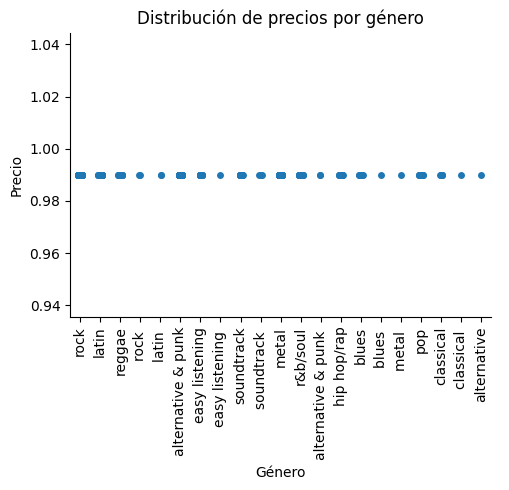

In [ ]:
sns.catplot(data=combined, x='GenreName', y='UnitPrice')
plt.title('Distribución de precios por género')
plt.xlabel('Género')
plt.ylabel('Precio')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Justificación:** el boxplot muestra el mínimo, máximo, mediana y si hay valores atípicos, lo cual es ideal para comparar distribuciones entre categorías.

- ¿Hay relación entre la duración de la canción y el género?

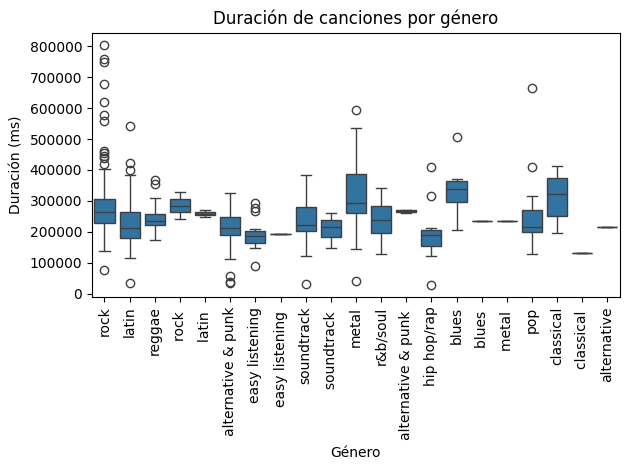

In [ ]:
sns.boxplot(data=combined, x='GenreName', y='Milliseconds')
plt.title('Duración de canciones por género')
plt.xlabel('Género')
plt.ylabel('Duración (ms)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Justificacion:** el boxplot permite ver de un vistazo si algún género tiende a tener canciones más largas o cortas, y qué tan dispersos son esos valores.

In [ ]:
conn = sqlite3.connect('canciones.db')
combined.to_sql('canciones', conn, if_exists='replace', index=False)
conn.close()